In [1]:
import requests
import pandas as pd
import time

In [2]:
BASE_URL = "https://www.ebi.ac.uk/gwas/rest/api/v2/associations"
params = {
    "efo_id": "MONDO_0005180",
    "show_child_traits": "false",
    "size": 100
}
all_associations =[] 
url = BASE_URL
first_request = True

while url:
    if first_request:
        response=requests.get(url,params=params)
        first_request=False
    else:
        response=requests.get(url)

    response.raise_for_status()
    data=response.json()

    page_records = data["_embedded"]["associations"]
    all_associations.extend(page_records)
    next_link = data.get("_links", {}).get("next", {}).get("href")
    url = next_link

    time.sleep(0.2)
    print(f"Fetched {len(all_associations)} associations so far...")

print(f"Done. Total associations collected: {len(all_associations)}")

Fetched 100 associations so far...
Fetched 200 associations so far...
Fetched 300 associations so far...
Fetched 400 associations so far...
Fetched 500 associations so far...
Fetched 600 associations so far...
Fetched 700 associations so far...
Fetched 800 associations so far...
Fetched 814 associations so far...
Done. Total associations collected: 814


In [3]:
CORE_TRAIT_STRINGS = {"Parkinson's disease", "Parkinson disease"}

flat_rows = []

for assoc in all_associations:
    reported = assoc.get("reported_trait", [])
    if not any(t in CORE_TRAIT_STRINGS for t in reported):
        continue

    genes = assoc.get("mapped_genes", [])
    if not genes:
        continue

    p_value = assoc.get("p_value")
    accession_id = assoc.get("accession_id")

    for gene in genes:
        flat_rows.append({
            "gene": gene,
            "p_value": p_value,
            "reported_trait": reported[0] if reported else None,
            "accession_id": accession_id
        })

print(f"Total gene-level rows after filtering: {len(flat_rows)}")

Total gene-level rows after filtering: 710


In [4]:
df = pd.DataFrame(flat_rows)
print(df.shape)
df.head()

(710, 4)


,gene,p_value,reported_trait,accession_id
0,SNCA,3.000000e-12,Parkinson's disease,GCST90475830
1,LRRK2,2.000000e-11,Parkinson's disease,GCST90475830
2,LDLRAD4,2.000000e-11,Parkinson's disease,GCST90479727
3,CDC42BPB,4.000000e-11,Parkinson's disease,GCST90479727
4,LRRK2,3.000000e-12,Parkinson's disease,GCST90479727


In [5]:
df['gene'].nunique()

337

In [6]:
df['p_value'].describe()

count     7.100000e+02
mean      5.309951e-07
std       1.371069e-06
min      4.000000e-170
25%       3.250000e-13
50%       8.500000e-10
75%       2.000000e-07
max       1.000000e-05
Name: p_value, dtype: float64

In [9]:
GENOME_WIDE_SIG = 5e-8
print(f'Original Shape b4 p_value cut-off: {df.shape}')

df_sig=df[df['p_value']<GENOME_WIDE_SIG].copy()
print(f'Shape after p_value cut-off: {df_sig.shape}')

df_sig_dedupe=df_sig.sort_values('p_value').drop_duplicates(subset='gene',keep='first')
print(f'Shape after dedupe: {df_sig_dedupe.shape}')

df_sig_dedupe.head()
#df_sig_dedupe

Original Shape b4 p_value cut-off: (710, 4)
Shape after p_value cut-off: (474, 4)
Shape after dedupe: (208, 4)


,gene,p_value,reported_trait,accession_id
154,SNCA,4.000000e-170,Parkinson's disease,GCST90308590
104,GBA1,3.000000e-90,Parkinson disease,GCST90428733
257,HMGN2P18,1.000000e-75,Parkinson's disease,GCST90308590
159,TMEM175,5.000000e-75,Parkinson's disease,GCST90308590
189,LINC02210-CRHR1,1.000000e-69,Parkinson's disease,GCST90308590


## EDA

In [10]:
expression=pd.read_csv('../datasets/processed/parkinsons_expression_dk.csv', index_col=0)
print(expression.shape)
expression.head()

(83, 15633)


,A1BG,A1BG-AS1,A2M,A2ML1,A3GALT2,A4GALT,AAAS,AACS,AADACL3,AADAT,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
label,,,,,,,,,,,,,,,,,,,,,
1,0.498266,0.664570,0.395276,0.449984,0.363204,0.390478,0.525830,0.752044,0.339071,0.687745,...,0.536216,0.510445,0.535749,0.470178,0.552097,0.394286,0.664582,0.675843,0.555539,0.487572
2,0.649068,0.578997,0.496142,0.651378,0.374900,0.376148,0.417392,0.670258,0.468810,0.680613,...,0.436584,0.460258,0.394620,0.439953,0.380107,0.495299,0.632483,0.483165,0.382653,0.504041
3,0.530613,0.623289,0.516300,0.387376,0.438570,0.548449,0.511302,0.785473,0.352448,0.571331,...,0.498757,0.624526,0.478582,0.350420,0.377683,0.361561,0.678239,0.732930,0.359707,0.450664
4,0.357235,0.577027,0.472538,0.407110,0.351562,0.439605,0.652987,0.752140,0.443812,0.564911,...,0.574279,0.579238,0.440776,0.394898,0.427183,0.380926,0.651013,0.845008,0.564132,0.371442
5,0.668703,0.533731,0.595773,0.524926,0.412263,0.446762,0.340154,0.699326,0.478007,0.617597,...,0.452369,0.543893,0.715963,0.371176,0.383864,0.502091,0.715354,0.328519,0.388377,0.557719


In [11]:
gwas_genes = set(df_sig_dedupe['gene'])
allen_genes = set(expression.columns)

overlap = gwas_genes & allen_genes
missing = gwas_genes - allen_genes

print(f"GWAS genes: {len(gwas_genes)}")
print(f"Overlap with Allen data: {len(overlap)}")
print(f"Missing from Allen data: {len(missing)}")

GWAS genes: 208
Overlap with Allen data: 129
Missing from Allen data: 79


In [12]:
overlap_genes = list(overlap)
expression_subset=expression[overlap_genes]

print(expression_subset.shape)
expression_subset.head()

(83, 129)


,NECTIN2,SLC41A1,SETD1A,BCKDK,PCGF3,USP8,MED12L,CCSER1,TIAL1,HIP1R,...,SLC2A13,ITPKB,GPM6B,DNASE1L1,TBC1D5,LAMTOR2,SH3GL2,NOL4,CAMK2D,MAPT
label,,,,,,,,,,,,,,,,,,,,,
1,0.370004,0.527316,0.643359,0.452036,0.655064,0.413220,0.561197,0.575108,0.628088,0.457298,...,0.471403,0.369959,0.552298,0.471680,0.506038,0.533322,0.722424,0.674075,0.514713,0.754927
2,0.663065,0.699248,0.391995,0.565069,0.521030,0.329571,0.367969,0.440676,0.598118,0.554449,...,0.420285,0.517588,0.718596,0.673839,0.676762,0.694070,0.544366,0.635469,0.579017,0.734886
3,0.449445,0.499358,0.565986,0.680312,0.508531,0.359349,0.585520,0.632048,0.513896,0.341385,...,0.552362,0.346938,0.554462,0.607806,0.574725,0.661548,0.702322,0.628386,0.486432,0.714271
4,0.334635,0.519426,0.649904,0.360955,0.522272,0.435311,0.542857,0.675302,0.686514,0.343327,...,0.526766,0.361511,0.370004,0.420582,0.478823,0.400430,0.714798,0.567527,0.406498,0.657349
5,0.712921,0.639109,0.520100,0.527738,0.456738,0.398624,0.322026,0.268703,0.547929,0.577452,...,0.520645,0.499867,0.712079,0.765744,0.725205,0.768227,0.624380,0.687148,0.799064,0.791514


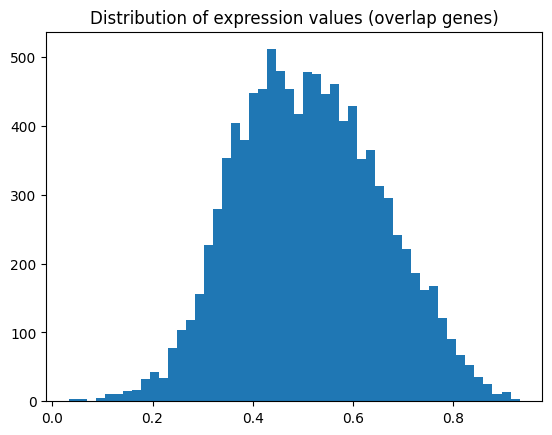

In [13]:
import matplotlib.pyplot as plt
plt.hist(expression_subset.values.flatten(), bins=50)
plt.title("Distribution of expression values (overlap genes)")
plt.show()

In [14]:
expression_subset.isna().sum().sum()

np.int64(258)

In [15]:
known_genes = ['SNCA', 'LRRK2', 'GBA1']
for gene in known_genes:
    if gene in expression_subset.columns:
        print(gene, "present")
    else:
        print(gene, "MISSING")

SNCA present
LRRK2 present
GBA1 MISSING


In [18]:
missing_per_gene = expression_subset.isna().sum()
missing_per_gene[missing_per_gene > 0].sort_values(ascending=False)

NECTIN2    2
ITGAE      2
STK39      2
RIT2       2
SYT10      2
          ..
PLPP4      2
CC2D2A     2
BAG3       2
WNT3       2
MAPT       2
Length: 129, dtype: int64

In [19]:
expression_subset.isna().sum(axis=1).sort_values(ascending=False).head()

label
73    129
72    129
1       0
60      0
59      0
dtype: int64

In [20]:
expression_clean = expression_subset.dropna(axis=0)
print(expression_clean.shape)

(81, 129)
